In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import os
import tarfile
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

In [3]:
# print shape of the matrix 
def shape(adata):
    print ('In the dataset there are:')
    print (f'{adata.obs.shape[0]} cells')
    print (f'{adata.var.shape[0]} genes')

In [ ]:
#name of the matrices and directory
matrices_directory= './0_raw_matrices/'

matriz1= 'tp4_r1.txt'
matriz2= 'tp4_r2_dm6_UMI.Matrix.txt'
matriz3= 'tp5_r1.txt'
matriz4= 'tp5_r2_dm6_UMI.Matrix.txt'


In [ ]:
##Changing flybaseIDs for gene names

#Reading the matrices to extract FliIDs
#Matriz 2
tmp_matriz_2 = sc.read_text(matrices_directory + matriz2)
matriz_2_names= pd.DataFrame(list(tmp_matriz_2.obs_names))
matriz_2_names.to_csv('./0_raw_matrices/matriz_2_flyIDs.csv', index=None, header=None)
del tmp_matriz_2

#Reading the matrices to extract FliIDs
#Matrix 4
tmp_matriz_4 = sc.read_text(matrices_directory + matriz4)
matriz_4_names= pd.DataFrame(list(tmp_matriz_4.obs_names))
matriz_4_names.to_csv('./0_raw_matrices/matriz_4_flyIDs.csv', index=None, header=None)
del tmp_matriz_4

In [5]:
##Obtaining the gane names manually for each matriz

# charge the 'matriz_4_flyIDs.csv' file generated in the webpage> http://flybase.org/convert/id
#download  the  unfiltered complete file with the buttom 'Validation table'
#save the file and it will be used in the next line to change the flyIDs to gene names

In [ ]:
#reading the converted flyIDs to gene names
#matriz 2
matriz_2_genenames= pd.read_csv('./0_raw_matrices/matriz_2_gene_names_from_flybase.txt', sep='\t',)
matriz_2_genenames.columns = ['submitted_item', 'validated_id', 'current_symbol']
matriz_2_genenames= matriz_2_genenames[['submitted_item', 'current_symbol']]

#reading the converted flyIDs to gene names
#matriz 4
matriz_4_genenames= pd.read_csv('./0_raw_matrices/matriz_4_gene_names_from_flybase.txt', sep='\t',)
matriz_4_genenames.columns = ['submitted_item', 'validated_id', 'current_symbol']
matriz_4_genenames= matriz_4_genenames[['submitted_item', 'current_symbol']]


In [8]:
#Replacing the flyIDs tfor the gene names and converting to an Anndat object
#matriz2
tmp1= pd.read_csv(matrices_directory + matriz2, sep='\t')

for fliIDs in matriz_2_genenames.itertuples():
    for name in tmp1.GENE:
        if fliIDs[1] == name:
            tmp1['GENE'] = tmp1['GENE'].replace([name],fliIDs[2])
            
tmp1= tmp1.set_index('GENE', )
tmp1.index.name = None
matriz_2 = sc.AnnData(tmp1).transpose()
del tmp1

#Replacing the flyIDs tfor the gene names and converting to an Anndat object
#matriz4
tmp2= pd.read_csv(matrices_directory + matriz4, sep='\t')

for fliIDs in matriz_4_genenames.itertuples():
    for name in tmp2.GENE:
        if fliIDs[1] == name:
            tmp2['GENE'] = tmp2['GENE'].replace([name],fliIDs[2])
            
tmp2= tmp2.set_index('GENE', )
tmp2.index.name = None
matriz_4 = sc.AnnData(tmp2).transpose()
del tmp2

/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-package

In [9]:
#Reading matriz 1 and 3 and converting to AnnData object
tmp1 = pd.read_table(matrices_directory + matriz1, sep=" ")
tmp2 = pd.read_table(matrices_directory + matriz3, sep=" ")

matriz_1 = sc.AnnData(tmp1).transpose()
matriz_3 = sc.AnnData(tmp2).transpose()

del tmp1
del tmp2

/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [12]:
matriz_1.obs_names_make_unique()
matriz_2.obs_names_make_unique()
matriz_3.obs_names_make_unique()
matriz_4.obs_names_make_unique()

In [13]:
matriz_1.var_names_make_unique()
matriz_2.var_names_make_unique()
matriz_3.var_names_make_unique()
matriz_4.var_names_make_unique()

In [14]:
#Obtaining the number of cells from each matrix to compare later how many cells I removed
tp4_r1_original_cellnumber= matriz_1.obs_names.value_counts().count()
tp4_r2_original_cellnumber= matriz_2.obs_names.value_counts().count()
tp5_r1_original_cellnumber= matriz_3.obs_names.value_counts().count()
tp5_r2_original_cellnumber= matriz_4.obs_names.value_counts().count()

original_number_cells_matrices= [['tp4_r1',tp4_r1_original_cellnumber ],
                                 ['tp4_r2',tp4_r2_original_cellnumber],
                                 ['tp5_r1', tp5_r1_original_cellnumber],
                                 ['tp5_r2', tp5_r2_original_cellnumber]]
df1 =pd.DataFrame (original_number_cells_matrices, columns= ['','stage'], )
df1.set_index(list(df1)[0], inplace=True)


In [15]:
shape (matriz_1)
shape (matriz_2)
shape (matriz_3)
shape (matriz_4)

In the dataset there are:
6428 cells
11691 genes
In the dataset there are:
10634 cells
13217 genes
In the dataset there are:
6255 cells
11547 genes
In the dataset there are:
11625 cells
13109 genes


In [16]:
#merging all matrices together
adata = matriz_1.concatenate([matriz_2,matriz_3, matriz_4],
batch_key='stage',
uns_merge='unique',
batch_categories=['tp4_r1', 'tp4_r2', 'tp5_r1', 'tp5_r2'],
index_unique=None,
join= 'inner',)
adata.var_names_make_unique()
adata

/tmp/ipykernel_166388/2741777366.py:2: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = matriz_1.concatenate([matriz_2,matriz_3, matriz_4],
/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 34942 × 9229
    obs: 'stage'

In [ ]:
## exporting matrix, genes, cell ids, and obs as tsv files. the reson for this that the current anndata object doesn't
##work properly, i think this is beacuse the values are not correctly charged. So, I am charging again the matrix from tsv files

destination_exported='1_exported_matrix_neuroblast'
os.system (f'mkdir {destination_exported}')
destination=f'./{destination_exported}'

pd.DataFrame(adata.var.index).to_csv(os.path.join(destination, "genes.csv" ),   sep = "\t", header=None, index=None)
pd.DataFrame(adata.obs.index).to_csv(os.path.join(destination, "barcodes.csv"), sep = "\t", header=None, index=None)
adata.obs.to_csv(os.path.join(destination, "metadata.csv"), sep = "\t")
adata.T.to_df().to_csv(f'./{destination_exported}/matrix.csv')
del adata


In [3]:
##reading the matrix
adata = sc.read('./1_exported_matrix_neuroblast/matrix.csv', cache=True) #Do not use read sc.read_10x_mtx, It does not work with the dataset
adata = adata.transpose()
#adata.X = adata.X.toarray()

##reading genes ids
genes = pd.read_csv('./1_exported_matrix_neuroblast/genes.csv',
                    header=None , sep='\t',
                    na_values= 'NaN',
                    keep_default_na=False)
genes.rename(columns={0:'gene_symbol'}, inplace=True)
genes.set_index('gene_symbol', inplace=True)
adata.var = genes

#reading cells' annotations
cols = ['stage']
metadata = pd.read_csv('./1_exported_matrix_neuroblast/metadata.csv',
                       sep='\t')
metadata.rename(columns={'Unnamed: 0':'cell_id'}, inplace=True)
metadata.set_index('cell_id', inplace=True)
adata.obs = metadata
adata.var_names_make_unique()
adata.obs_names_make_unique ()


/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [4]:
adata.var_names_make_unique ()
adata.obs_names_make_unique ()

In [5]:
###adding the annotated TF that I predicted
tf_predicted= pd.read_csv('3_TF_predicted/droso_output_true_annotated.csv', sep=',', usecols=['gene_name'])
tf_list = set(tf_predicted['gene_name'])
print(f'The total nmber of predicted TFs is: {len(tf_list)}')
adata.var['is_TF'] = adata.var_names.isin(tf_list)
print(f'The number of predicted TFs found is: {len(adata.var[adata.var['is_TF'] == True])}')
#adata.var['is_TF'].value_counts()

The total nmber of predicted TFs is: 958
The number of predicted TFs found is: 772


In [6]:
adata.var["ribo"] = adata.var_names.str.startswith(('RpS', 'RpL'))
sc.pp.calculate_qc_metrics(adata, qc_vars=["ribo"], inplace=True)
#adata.var.query('ribo == True') # check the ribosomal genes

In [7]:
adata.var["mt"] = adata.var_names.str.startswith("mt:")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
#adata.var.query('mt == True')# check the mitochondrial genes

In [8]:
sc.pp.scrublet(adata, batch_key="stage")

In [9]:
#thisis just for comparison before and after filtering
df1= adata.copy()
df1

AnnData object with n_obs × n_vars = 34942 × 9229
    obs: 'stage', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'is_TF', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt'
    uns: 'scrublet'

In [10]:
    
## creating a boxplot to show the data distribution
def range_values_in_dataset (plot_title='Non normalized dataset'):
    tmp1=pd.DataFrame(adata.X)
    uniques=np.unique (tmp1)
    outliers_annotations = dict(markerfacecolor='g', marker='D', markersize=4, alpha=0.1,)
    box_annotations= dict(linewidth=1, color='blue', alpha=0.9 , facecolor='teal' )
    plt.boxplot (uniques, patch_artist=True, 
                 flierprops=outliers_annotations, 
                 boxprops= box_annotations )
    plt.ylabel('Unique range of values in the dataset ')
    plt.title (plot_title) ## you can notice it because the range is large
    plt.tick_params(labelbottom=False, bottom=False)
    sb.displot(uniques, kind="kde", legend=False)
    plt.tick_params(labelleft=False, left=False, )
    del uniques, tmp1

# creating QC violin plots   
def qc_violin_plots (xvalue='genotype', xlabels=False, jitter=0.25, size=1.5):
    fig, axs = plt.subplots(ncols=3, figsize=(14,5),
                            constrained_layout=True ) #multipanel Fig

    fig = sb.violinplot(x=adata.obs[xvalue], 
                        y=adata.obs['n_genes_by_counts'],
                        data=adata.obs, ax=axs[0])
    fig= sb.stripplot(x=adata.obs[xvalue], 
                      y=adata.obs['n_genes_by_counts'], 
                      data=adata.obs, jitter=jitter, 
                      color='black', size=size, ax=axs[0])
    fig.axes.get_xaxis().set_visible(xlabels)
    fig.set_title('number of genes', fontweight ='bold')

    fig1 = sb.violinplot(x=adata.obs[xvalue],
                         y=adata.obs['total_counts'],
                         data=adata.obs, ax=axs[1])
    fig1= sb.stripplot(x=adata.obs[xvalue],
                       y=adata.obs['total_counts'],
                       data=adata.obs, jitter=jitter,
                       color='black', size=size,ax=axs[1])
    fig1.axes.get_xaxis().set_visible(xlabels)
    fig1.set_title('total counts', fontweight ='bold')


    fig2 = sb.violinplot(x=adata.obs[xvalue],
                         y=adata.obs['pct_counts_mt'],
                         data=adata.obs, ax=axs[2])
    fig2= sb.stripplot(x=adata.obs[xvalue],
                       y=adata.obs['pct_counts_mt'],
                       data=adata.obs, jitter=jitter, 
                       color='black', ax=axs[2], 
                       size=size, marker="D")
    fig2.axes.get_xaxis().set_visible(xlabels)
    fig2.set_title('% mitochondrial counts', fontweight ='bold')
    
# creating QC scatter plots   
def qc_scatter_plots (cells_to_filter=30000,genes_to_filter=700):
    fig, axs = plt.subplots(ncols=2, figsize=(15,6), 
                            constrained_layout=True, sharey=False, sharex=False )
    p0 = axs[0].scatter(x=adata.obs['total_counts'],
                   y=adata.obs['n_genes_by_counts'],
                   c=adata.obs['pct_counts_mt'],
                   cmap="rainbow",
                   s=0.1)
    axs[0].set_xlabel('total_counts')
    axs[0].set_ylabel('n_genes')
    axs[0].set_title('% mitochondrial counts')
    axs[0].axvline(cells_to_filter, color='red') ####This is the min_counts to filter
    fig.colorbar(p0, 
                 aspect=50,
                 ax=axs[0],
                 pad=0)

    #Ploting a reduced number of cells filtered by n_counts
    obtaining_obs_to_plot = sc.get.obs_df(adata, 
                                          ['total_counts', 'n_genes_by_counts', 'pct_counts_mt'])
    reduced_num_cells= obtaining_obs_to_plot[obtaining_obs_to_plot['total_counts'] < cells_to_filter]
    p1 = axs[1].scatter(x=reduced_num_cells['total_counts'],
                   y=reduced_num_cells['n_genes_by_counts'],
                   c=reduced_num_cells['pct_counts_mt'],
                   cmap="rainbow",
                   s=0.1)

    axs[1].set_xlabel('total_counts')
    axs[1].set_ylabel('n_genes')
    axs[1].set_title('% mitochondrial counts')
    axs[1].axhline(y=genes_to_filter, color='red') ####This is the min_counts to filter
    fig.colorbar(p1,
                 aspect=50,
                 ax=axs[1],
                 pad=0)
    
    total_cells_label=int (adata.obs['total_counts'].shape[0] )
    reduced_cells_label= reduced_num_cells.shape[0]
    above_cells= total_cells_label-reduced_cells_label
    text1= f'{total_cells_label} cells.\n{reduced_cells_label} below \n{above_cells} above'
    
    reduced_num_cells2=reduced_num_cells[reduced_num_cells['n_genes_by_counts'] > genes_to_filter]
    below_cells_genes= reduced_num_cells.shape[0] - reduced_num_cells2.shape[0]
    text2= f'{reduced_cells_label} cells \n {reduced_num_cells2.shape[0]} above \n{below_cells_genes} below'
    axs[0].text(50000,3500, text1 )
    axs[1].text(12000,3000, text2 ,horizontalalignment='right')

# creating QC scatter plots2   
def qc_scatter_plots2 (mt_percentage=5):
    fig, axs = plt.subplots(ncols=2, figsize=(15,6), 
                            constrained_layout=True, sharey=False, sharex=False )
    p0 = axs[0].scatter(x=adata.obs['total_counts'],
                   y=adata.obs['pct_counts_mt'],
                   c=adata.obs['n_genes_by_counts'],
                   # cmap="rainbow",
                   s=0.1)
    axs[0].set_xlabel('total_counts')
    axs[0].set_ylabel('% mitochondrial counts')
    axs[0].set_title('% mitochondrial counts')
    axs[0].axhline(mt_percentage, color='red') #### This is the min_counts to filter
    fig.colorbar(p0, 
                 aspect=50,
                 ax=axs[0],
                 pad=0)
    
    
    # Ploting a reduced number of cells filtered by n_counts
    p1 = axs[1].scatter(x=adata.obs['n_genes_by_counts'],
                   y=adata.obs['pct_counts_mt'],
                   c=adata.obs['total_counts'],
                   #cmap="rainbow",
                   s=0.1)

    axs[1].set_xlabel('n_genes')
    axs[1].set_ylabel('% mitochondrial counts')
    axs[1].set_title('% mitochondrial counts')
    axs[1].axhline(mt_percentage, color='red') #### This is the min_counts to filter
    fig.colorbar(p1,
                 aspect=50,
                 ax=axs[1],
                 pad=0)
    
    obtaining_obs_to_plot = sc.get.obs_df(adata, 
                                          ['total_counts', 'n_genes_by_counts', 'pct_counts_mt'])
    reduced_num_cells= obtaining_obs_to_plot[obtaining_obs_to_plot['pct_counts_mt'] < mt_percentage]
    total_cells_label=int (adata.obs['pct_counts_mt'].shape[0] )
    reduced_cells_label= reduced_num_cells.shape[0]
    above_cells= total_cells_label-reduced_cells_label
    text1= f'{total_cells_label} cells.\n{reduced_cells_label} below \n{above_cells} above'
    axs[0].text(30000,11, text1 )    
    

# creating QC counts distribution plots   
def qc_counts_distribution_plot (min_counts=1200, max_counts=15000):
    # Thresholding decision: counts
    fig, axs = plt.subplots(ncols=3, figsize=(15,6), 
                            constrained_layout=True ) #multipanel Fig

    p3 = sb.histplot(adata.obs['total_counts'],
                     kde=True, bins=200,ax=axs[0])
    p3.axvline(min_counts, color='red')
    p3.axvline(max_counts, color='red')
    p3.set_xlim (xmin=0, xmax=60000)          # xmax=40000
    p3.set_ylabel('# cells')
    p3.set_xlabel('total counts')


    p4 = sb.histplot(adata.obs['total_counts'][adata.obs['total_counts']<5000],
                     kde=False, bins=100, ax=axs[1])
    #p4.axvline(400, color='yellow')
    p4.axvline(min_counts, color='red') ####This is the min_counts to filter
    p4.set_xlim (xmin=0, )          
    p4.set_ylabel('# cells')
    p4.set_xlabel('total counts')

    p5 = sb.histplot(adata.obs['total_counts'][adata.obs['total_counts']>5000],
                     kde=False, ax=axs[2])
    p5.set_xlim (xmax=60000, )          
    p5.set_ylabel('# cells')
    p5.set_xlabel('total counts')
    p5.axvline(max_counts, color='red') ####This is the max_counts to filter


    total_cells_label=int (adata.obs['total_counts'].shape[0] )
    below_label=adata.obs['total_counts'][adata.obs['total_counts']<min_counts].shape[0]
    above_label=adata.obs['total_counts'][adata.obs['total_counts']>max_counts].shape[0]
    filter_label=total_cells_label- (below_label+above_label)
    text1= f'{total_cells_label} cells.\n{below_label} below \n{above_label} above \n{filter_label} remaining'
    axs[0].text(7000,3000, text1 )

# creating QC genes distribution plots   
def qc_genes_distribution_plot (min_genes=700):
    #Thresholding decision: genes
    fig, axs = plt.subplots(ncols=2, figsize=(15,6),
                            constrained_layout=True, ) #multipanel Fig

    p6 = sb.histplot(adata.obs['n_genes_by_counts'],
                     kde=True, ax=axs[0])
    p6.axvline(min_genes, color='red')
    p6.set_ylabel('# cells')
    p6.set_xlabel('number of genes')

    p7 = sb.histplot(adata.obs['n_genes_by_counts'][adata.obs['n_genes_by_counts']<1000],
                     kde=False, ax=axs[1])
    #p7.axvline(40, color='yellow')
    p7.axvline(min_genes, color='red')####This is the min_genes to filter
    p7.set_ylabel('# cells')
    p7.set_xlabel('number of genes')

    total_cells_label=int (adata.obs['n_genes_by_counts'].shape[0])
    below_label= adata.obs['n_genes_by_counts'][adata.obs['n_genes_by_counts']<min_genes].shape[0]
    filter_label=total_cells_label - below_label
    text1= f'{total_cells_label} cells.\n{below_label} below \n{filter_label} remaining'
    axs[0].text(2000,1000, text1 )
    

# Test different QC genes filters and plot the results without actually filtering   
def filtering_parameters (adata, 
                          min_counts=1500,
                          max_counts = 25000,
                          mt_percentage= 13,
                          min_genes = 500,
                          min_cells=10):
    '''Review multiple filtering parameters'''
    sc.settings.verbosity = 0
    shape(adata)

    sc.pp.filter_cells(adata, min_counts = min_counts)
    print('Number of cells after min_count filter: {:d}'.format(adata.n_obs))

    sc.pp.filter_cells(adata, max_counts = max_counts)
    print('Number of cells after max_count filter: {:d}'.format(adata.n_obs))

    adata = adata[adata.obs['pct_counts_mt'] < mt_percentage]
    print('Number of cells after MT_filter: {:d}'.format(adata.n_obs))

    sc.pp.filter_cells(adata, min_genes = min_genes)
    print('Number of cells after min gene filter: {:d}'.format(adata.n_obs))

    #Filtering GENES:
    print('Total number of genes: {:d}'.format(adata.n_vars))

    # Min 20 cells - filters out 0 count genes
    sc.pp.filter_genes(adata, min_cells=min_cells)
    print('Number of genes after cell filter: {:d}'.format(adata.n_vars))

    # See how many cells and genes left after filtering
    shape(adata)
    
    #Data quality summary plots
    sc.pl.scatter(adata, 'total_counts',
                   'n_genes_by_counts',
                   color='pct_counts_mt',
                   title= f'{mt_percentage}% mitochondrial counts after filtering',
                   color_map='rainbow', )


#Check how many genes form the ones we want to analyze remain after filtering
def genes_in_dataset (genes_list, dataset,):
    global found_genes
    global no_found_genes
    found_genes=[]
    no_found_genes=[]
    for gene in genes_list:
        if gene in dataset.raw.var_names:
            found_genes.append (gene)
        else:
            no_found_genes.append (gene, )
    #return found_genes, no_found_genes
    print (f'We found {len (found_genes)} out of {len(ALL_GENES)}')
    print (f'These genes are not in the datset: {no_found_genes}')

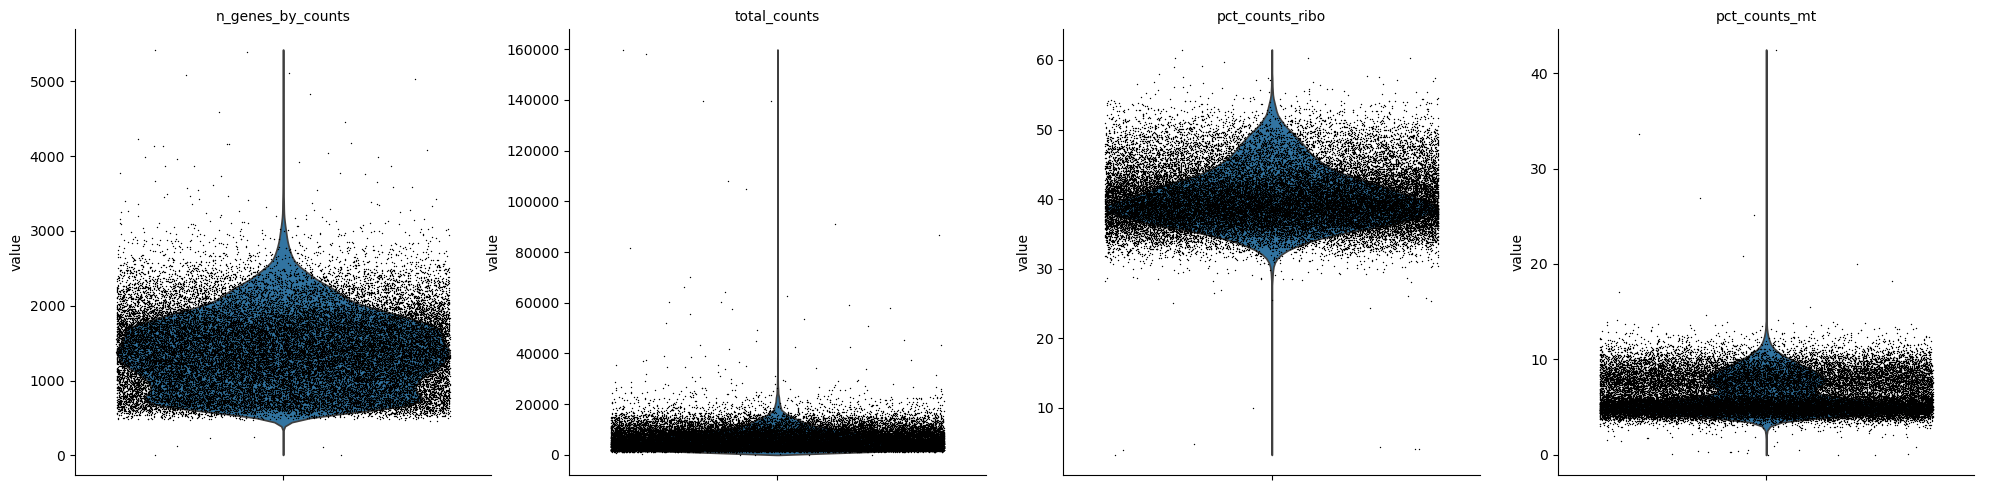

In [11]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_ribo', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, save='_plots_droso_1.pdf')

## Note: this plot was not working correctly in scanpy 1.6
## So I wrote my verion that you can see in the function qc_violin_plots ().
## So now both functions are working

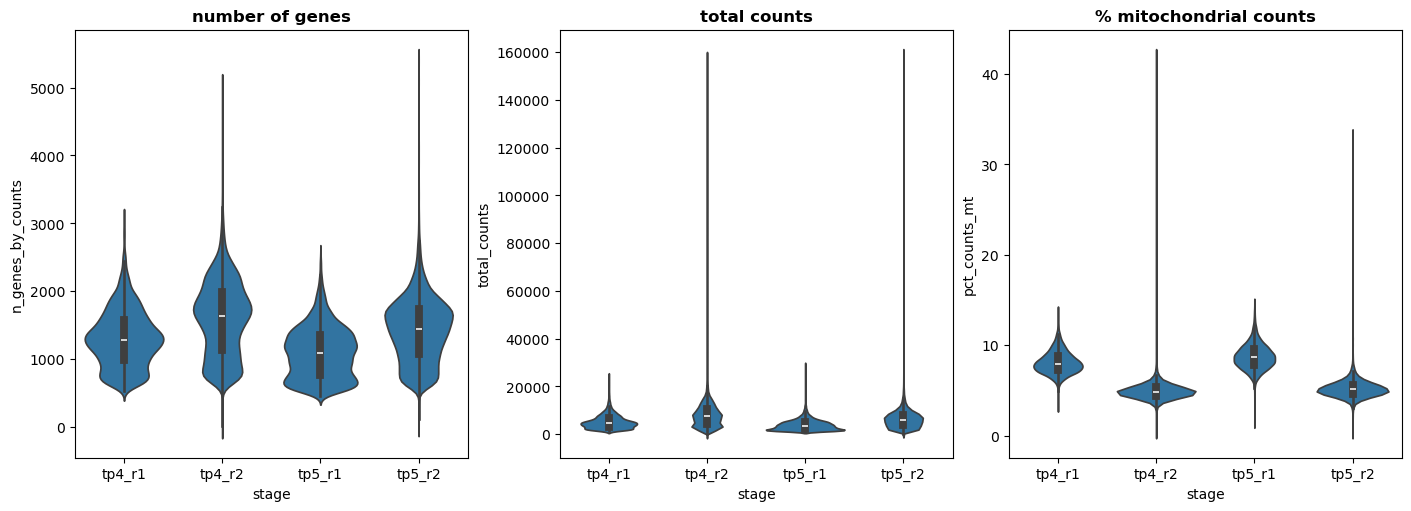

In [12]:
qc_violin_plots (xvalue='stage', xlabels=True, size=0)

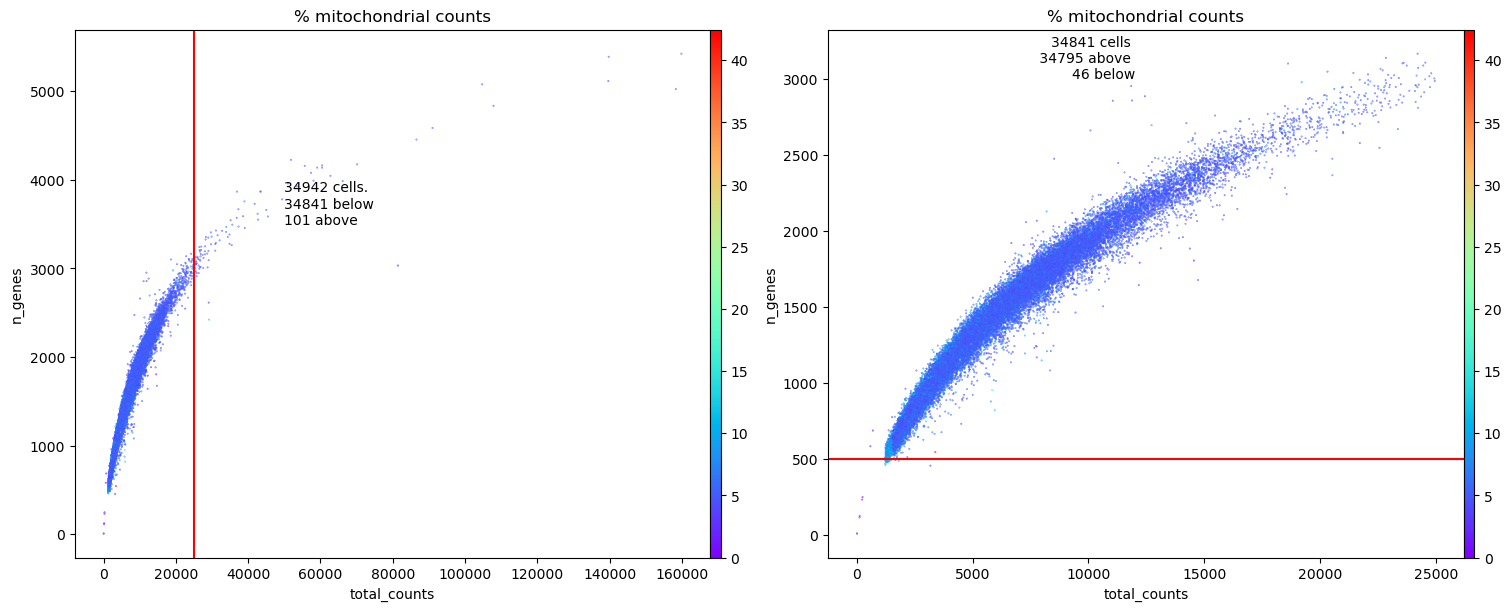

In [13]:
qc_scatter_plots (cells_to_filter=25000, genes_to_filter=500)

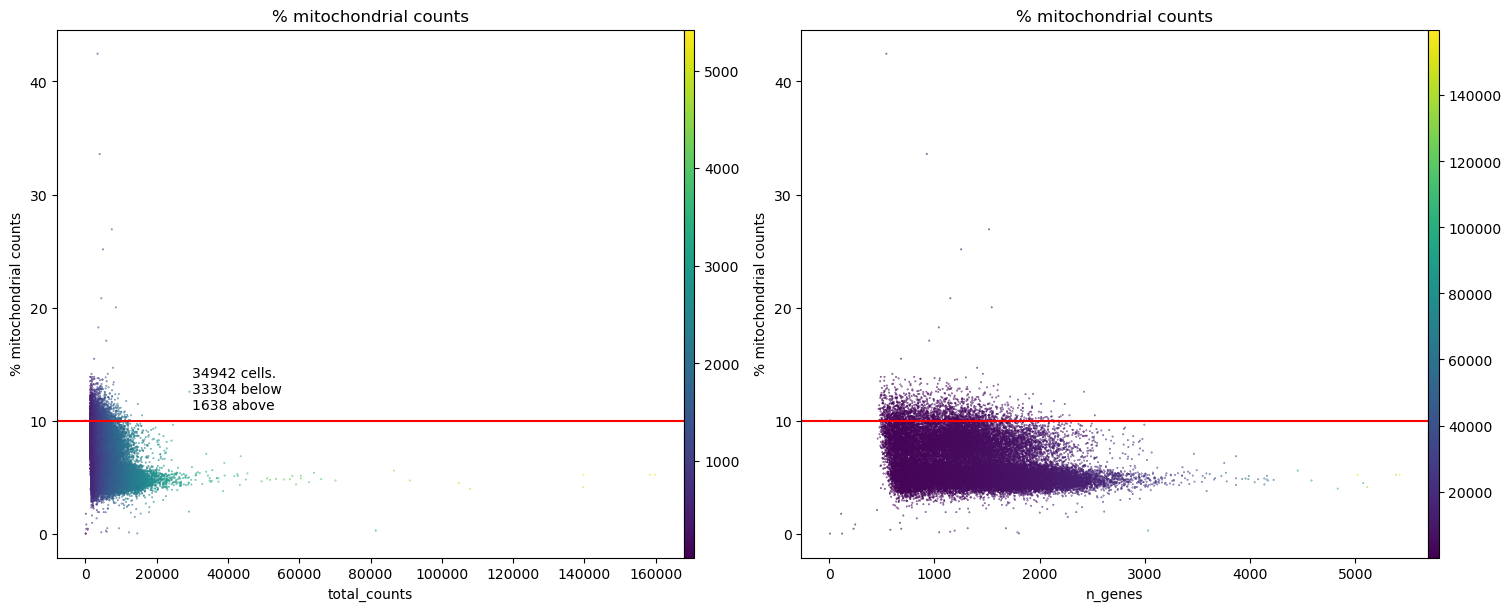

In [14]:
qc_scatter_plots2(mt_percentage=10)

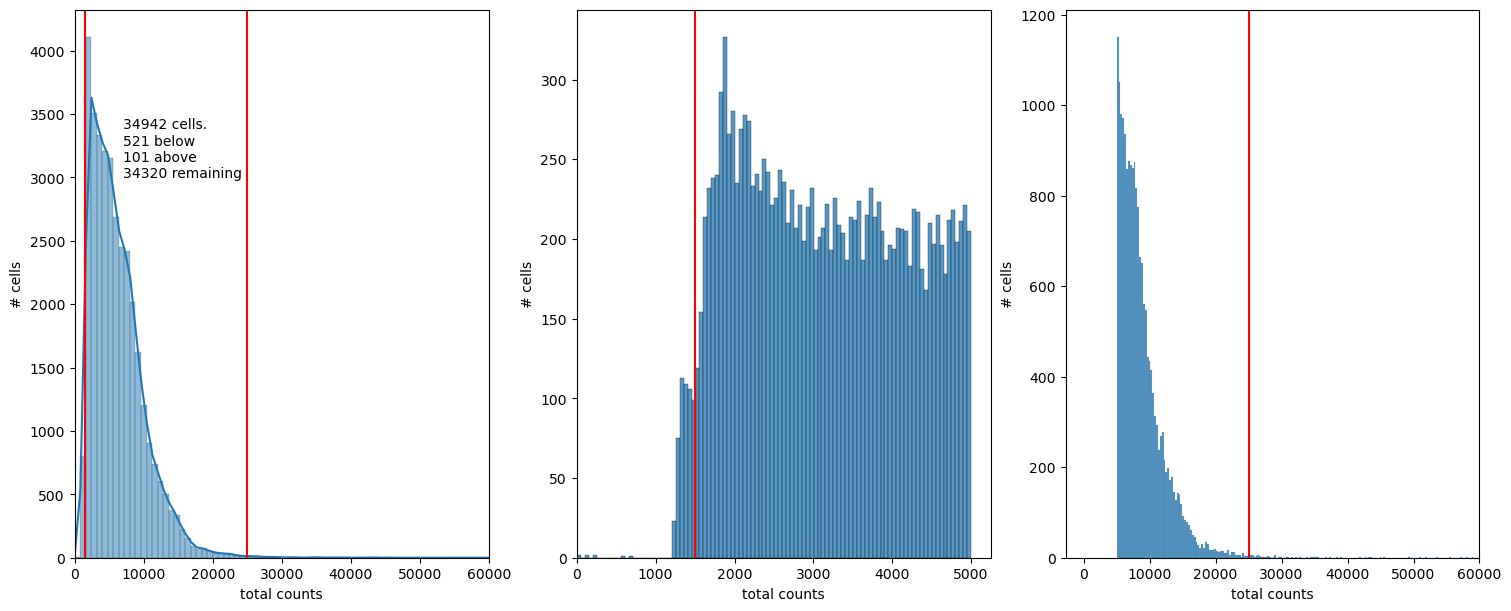

In [15]:
qc_counts_distribution_plot (min_counts=1500, max_counts=25000)

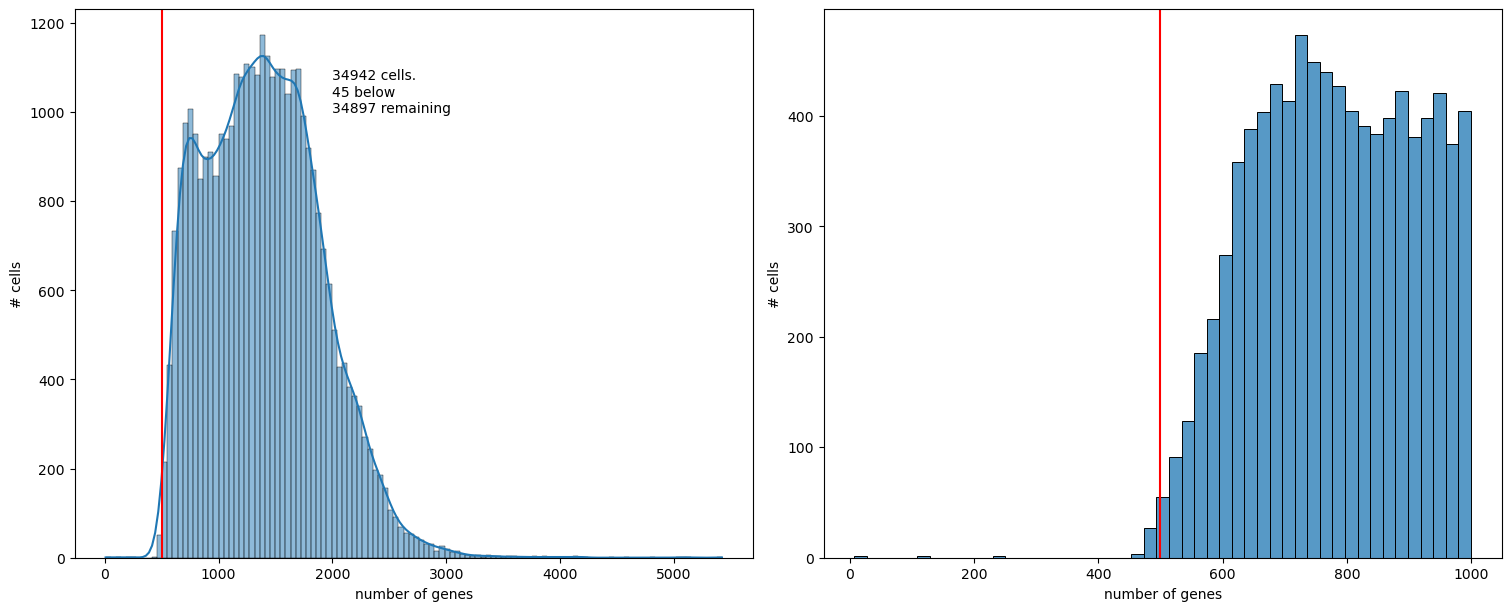

In [16]:
qc_genes_distribution_plot (min_genes=500)

In [17]:
## DO NOT RUN THIS CODE TWICE I JUST RAN IT TO EVALUATE THE DIFFERENT FILTERS
## testing filtering quality control thresholds

#filtering_parameters (adata, mt_percentage= 15)

In [18]:
## DO NOT RUN THIS CODE TWICE I JUST RAN IT TO EVALUATE THE DIFFERENT FILTERS
## testing filtering quality control thresholds

#filtering_parameters (adata, mt_percentage= 13)

In [19]:
## DO NOT RUN THIS CODE TWICE I JUST RAN IT TO EVALUATE THE DIFFERENT FILTERS
## testing filtering quality control thresholds

#filtering_parameters (adata, mt_percentage= 10)

In [20]:
## DO NOT RUN THIS CODE TWICE I JUST RAN IT TO EVALUATE THE DIFFERENT FILTERS
## testing filtering quality control thresholds

#filtering_parameters (adata, mt_percentage= 8)

In the dataset there are:
34942 cells
9229 genes
Number of cells after min_count filter: 34421
Number of cells after max_count filter: 34320
Number of cells after MT_filter: 34316
Number of cells after Ribo_filter: 33535


/home/beetle/miniconda3/envs/scanpy_001/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:170: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_genes"] = number


Number of cells after min gene filter: 33534
Total number of genes: 9229
Number of genes after cell filter: 8768
In the dataset there are:
33534 cells
8768 genes


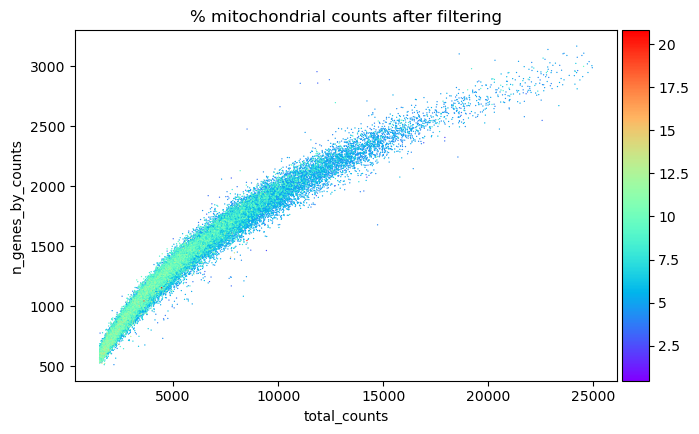

In [21]:
## Filtering CELLS according to identified quality control thresholds
#values to filter
min_counts=1500,
max_counts = 25000,
mt_percentage= 25,
ribo_percentage= 50,

min_genes = 500,
min_cells=10

shape(adata)

sc.pp.filter_cells(adata, min_counts = min_counts)
print('Number of cells after min_count filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, max_counts = max_counts)
print('Number of cells after max_count filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < mt_percentage]
print('Number of cells after MT_filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_ribo'] < ribo_percentage]
print('Number of cells after Ribo_filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes = min_genes)
print('Number of cells after min gene filter: {:d}'.format(adata.n_obs))

#Filtering GENES:
print('Total number of genes: {:d}'.format(adata.n_vars))

# Min 20 cells - filters out 0 count genes
sc.pp.filter_genes(adata, min_cells=min_cells)
print('Number of genes after cell filter: {:d}'.format(adata.n_vars))

# See how many cells and genes left after filtering
shape(adata)
    
#Data quality summary plots
sc.pl.scatter(adata, 'total_counts',
              'n_genes_by_counts',
               color='pct_counts_mt',
               title='% mitochondrial counts after filtering',
               color_map='rainbow',save='_QC_plot_after_filtering_droso_2.pdf' )

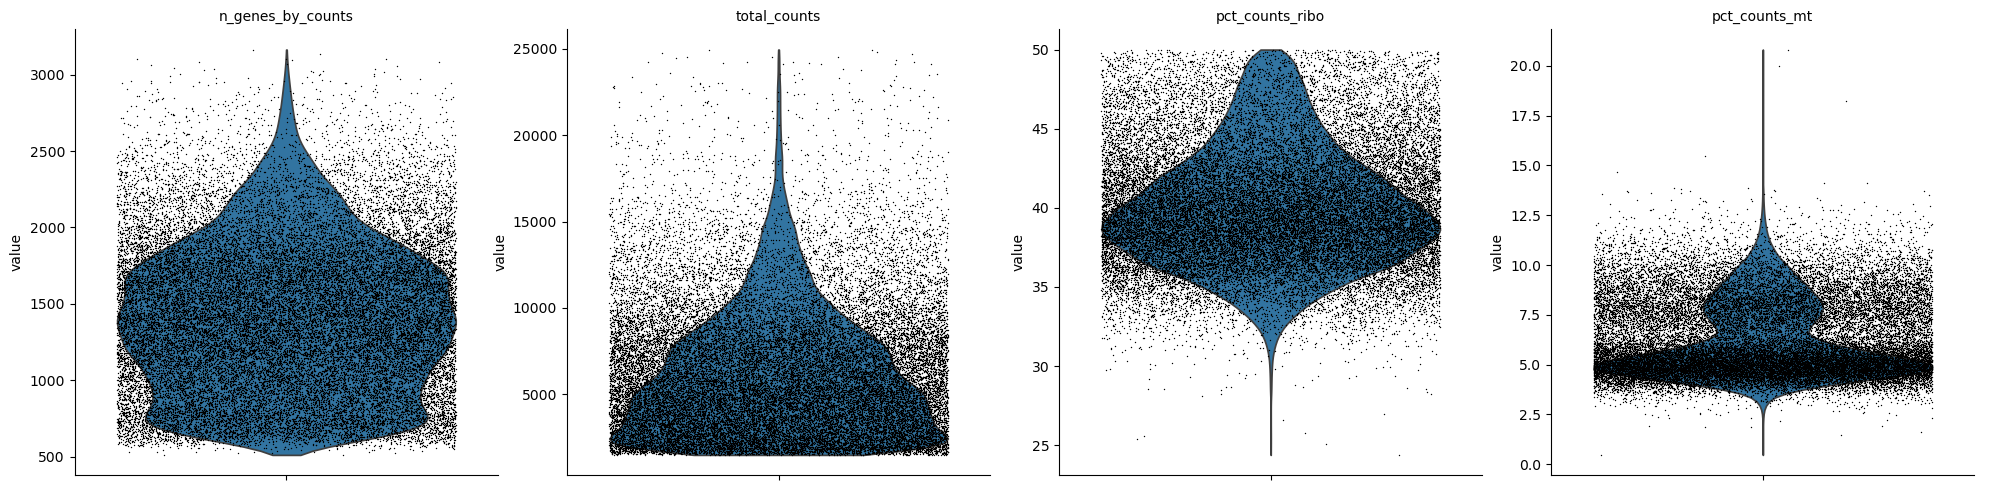

In [22]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_ribo', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True, save='_plots_after_filtering_droso_2.pdf')


In [23]:
#Removing mitochondrial counts from the analysis
mt_genes_list= list(adata.var[(adata.var['mt']== True)].index)
mt_genes=np.in1d (adata.var_names.values.astype(str), mt_genes_list)
adata= adata[:, ~mt_genes]
adata

/tmp/ipykernel_213131/3386185150.py:3: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  mt_genes=np.in1d (adata.var_names.values.astype(str), mt_genes_list)


View of AnnData object with n_obs × n_vars = 33534 × 8741
    obs: 'stage', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts'
    var: 'is_TF', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'n_cells'
    uns: 'scrublet'

In [24]:
#Removing ribosomal counts from the analysis
ribo_genes_list= list(adata.var[(adata.var['ribo']== True)].index)
ribo_genes=np.in1d (adata.var_names.values.astype(str), ribo_genes_list)
adata= adata[:, ~ribo_genes]
adata

/tmp/ipykernel_213131/1979858822.py:3: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  ribo_genes=np.in1d (adata.var_names.values.astype(str), ribo_genes_list)


View of AnnData object with n_obs × n_vars = 33534 × 8651
    obs: 'stage', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts'
    var: 'is_TF', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'n_cells'
    uns: 'scrublet'

In [25]:
#saving layer of normalized data that can be used for differential expression
adata.raw = adata
#creating a new layer
adata.layers["counts"] = adata.raw.X.copy()

In [26]:
##Normalization with scanpy method (CPM normalization)
#normalize to depth 10000
sc.pp.normalize_total(adata,
                      target_sum=1e6, 
                      key_added= 'norm',)

In [27]:
adata

AnnData object with n_obs × n_vars = 33534 × 8651
    obs: 'stage', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm'
    var: 'is_TF', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'n_cells'
    uns: 'scrublet'
    layers: 'counts'

In [28]:
#logaritmize
sc.pp.log1p(adata,)


In [32]:
shape (adata)

In the dataset there are:
33534 cells
8651 genes


In [33]:
shape(adata)
print ('Before filtering, shape and datacounts by genotype and age:')
print(adata.obs['stage'].value_counts())

In the dataset there are:
33534 cells
8651 genes
Before filtering, shape and datacounts by genotype and age:
stage
tp5_r2    11143
tp4_r2    10232
tp4_r1     6428
tp5_r1     5731
Name: count, dtype: int64


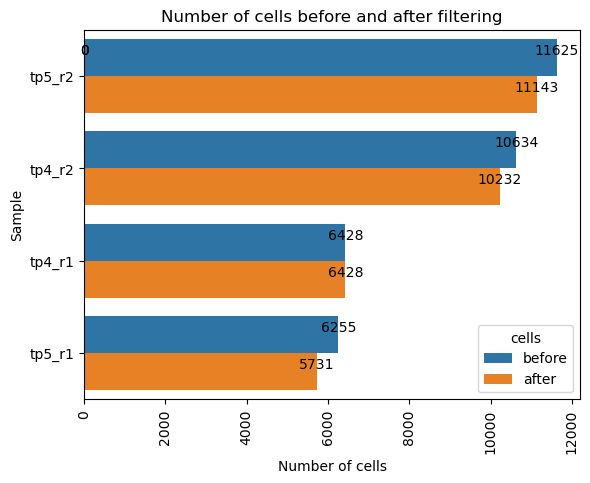

In [39]:
# df1 was created early in the analysis
df= pd.DataFrame(df1.obs['stage'].value_counts())
df['cells'] = 'before'
df2 = pd.DataFrame(adata.obs['stage'].value_counts())
df2['cells'] = 'after'

# Concatenate the DataFrames
comparing_datasets = pd.concat([df, df2])

# Create the bar plot
ax = sb.barplot(y=comparing_datasets.index,
                x=comparing_datasets['count'],  # Ensure 'count' is the correct column name
                hue=comparing_datasets['cells'],
                saturation=0.8)

# Add labels with values
for idx, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_width():.0f}', (p.get_x() + p.get_width(), p.get_y() + p.get_height() - 0.2),
                ha='center', va='bottom', color='black', size=10)

plt.xticks(rotation=90)
plt.xlabel('Number of cells')
plt.ylabel('Sample')
plt.title('Number of cells before and after filtering')
plt.savefig('figures/original_cell_numbers.pdf')
plt.show()


In [40]:
#Filtering cells expressing repo gene
adata= adata[adata[:, 'repo'].X == 0, :]
adata

View of AnnData object with n_obs × n_vars = 32112 × 8651
    obs: 'stage', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm'
    var: 'is_TF', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'n_cells'
    uns: 'scrublet', 'log1p'
    layers: 'counts'

In [41]:
%%time
#Filtering brain neuroblasts. They should not express HOX genes
adata_no_ubx = adata[adata[: , 'Ubx'].X == 0, :]
adata_no_antp= adata_no_ubx[adata_no_ubx[: , 'Antp'].X == 0, :]
adata_no_lab= adata_no_antp[adata_no_antp[: , 'lab'].X == 0, :]
adata_no_pb= adata_no_lab[adata_no_lab[: , 'pb'].X == 0, :]
adata_no_dfd= adata_no_pb[adata_no_pb[: , 'Dfd'].X == 0, :]
adata_no_scr= adata_no_dfd[adata_no_dfd[: , 'Scr'].X == 0, :]
adata_no_abdA= adata_no_scr[adata_no_scr[: , 'abd-A'].X == 0, :]
adata_no_abdB= adata_no_abdA[adata_no_abdA[: , 'Abd-B'].X == 0, :]
adata_nohox= adata_no_abdB
adata_nohox
#adata=adata_nohox

CPU times: user 744 ms, sys: 14.2 s, total: 14.9 s
Wall time: 15 s


View of AnnData object with n_obs × n_vars = 10425 × 8651
    obs: 'stage', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm'
    var: 'is_TF', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'n_cells'
    uns: 'scrublet', 'log1p'
    layers: 'counts'

In [42]:
%%time
#Filtering VNC neuroblasts. They should express HOX genes
adata_hox_barcodes= list(set(adata.obs_names) - set(adata_nohox.obs_names))
len(adata_hox_barcodes)
adata_hox=adata[adata_hox_barcodes].copy()
adata_hox

CPU times: user 548 ms, sys: 9.29 s, total: 9.84 s
Wall time: 15 s


AnnData object with n_obs × n_vars = 21687 × 8651
    obs: 'stage', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm'
    var: 'is_TF', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'n_cells'
    uns: 'scrublet', 'log1p'
    layers: 'counts'

In [43]:
#Annotating brain and vnc neuroblasts
adata.obs['hox'] = 'Hox'
adata.obs.loc[list(adata_nohox.obs_names), 'hox'] = 'No_hox'

/tmp/ipykernel_213131/626066329.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['hox'] = 'Hox'


In [44]:
### saving log transformed and normalized dataset
normalized_and_log_droso_neuroblasts_dataset= '2_droso_neuroblasts_normalized_and_log_dataset.h5ad' #This file is going to be used for the the downstream analysis
adata.write(normalized_and_log_droso_neuroblasts_dataset)
os.mkdir ('4_droso_neuroblast_dataset')
os.system (f'mv {normalized_and_log_droso_neuroblasts_dataset} ./4_droso_neuroblast_dataset/')

0

In [6]:
#Making sure that we obtained the result we wanted
jj= sc.read_h5ad(f'./4_droso_neuroblast_dataset/{normalized_and_log_droso_neuroblasts_dataset}')
jj

AnnData object with n_obs × n_vars = 32112 × 8651
    obs: 'stage', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox'
    var: 'is_TF', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'

In [ ]:
del jj